In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import skewnorm
import statsmodels.api as sm

from tqdm.notebook import tqdm
import pickle
import pandas as pd
import os

import sys 
sys.path.insert(0, '../src/')

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

In [2]:
# VIDS here
import VIDS_claude.vids as vids

In [3]:
a = 0.5
b = 1.0

N = 500 # dataset size
m = 10  # subsample size
n = 500 # training size
J = 50  # number of subsamples
dtype = 'float32'

In [4]:
Xs = np.sort(np.random.uniform(low=0.0, high=a, size=N)).astype(dtype).reshape(-1,1)
new_Xs = np.sort(np.random.uniform(low=0.0, high=b, size=N)).astype(dtype).reshape(-1,1)

v = 0.1*Xs
new_v = 0.1*new_Xs

epsilon = np.array([np.random.normal(0, v[i]) for i in range(N)])
new_epsilon = np.array([np.random.normal(0, new_v[i]) for i in range(N)])

beta = 1.0
Ys = beta * Xs + epsilon.reshape(-1,1)
new_Ys = beta * new_Xs + new_epsilon.reshape(-1,1)

In [5]:
print(Xs.shape)
print(Ys.shape)
print(new_Xs.shape)
print(new_Ys.shape)

(500, 1)
(500, 1)
(500, 1)
(500, 1)


In [6]:
# shuffling
idx = np.random.choice(N, N, replace=False)
Xs = torch.Tensor(Xs[idx])
Ys = torch.Tensor(Ys[idx])
v = torch.Tensor(v[idx])

idx = np.random.choice(N, N, replace=False)
new_Xs = torch.Tensor(new_Xs[idx])
new_Ys = torch.Tensor(new_Ys[idx])
new_v = torch.Tensor(new_v[idx])

In [7]:
print(Xs.shape)
print(Ys.shape)
print(new_Xs.shape)
print(new_Ys.shape)

torch.Size([500, 1])
torch.Size([500, 1])
torch.Size([500, 1])
torch.Size([500, 1])


In [8]:
d = Xs.shape[1] # data dimension
d

1

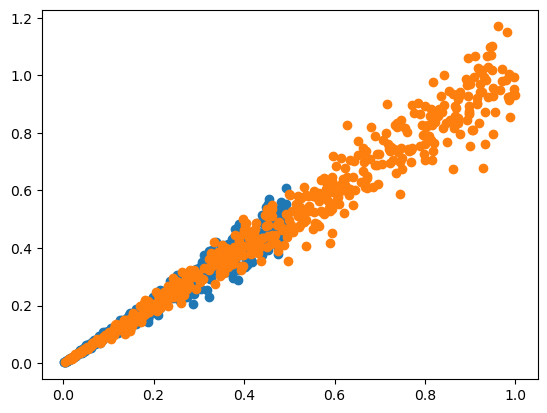

In [9]:
plt.scatter(Xs[:,0], Ys[:,0])
plt.scatter(new_Xs[:,0], new_Ys[:,0])
plt.show()

In [10]:
# Model setup
input_dim = 1
embedding_dim = 10
output_dim = 1

In [11]:
# 1. Create and pre-train embedding network
print("\n--- Pre-training embedding network ---")
embedding_net = vids.FCEmbedding(input_dim, embedding_dim)
pretrain_head = nn.Linear(embedding_dim, output_dim)

embedding_net, model = vids.pretrain_embedding(
    embedding_net,
    pretrain_head,
    Xs,
    Ys,
    task="regression",
    epochs=1000,
    lr=1e-2,
)


--- Pre-training embedding network ---
  Pre-train Epoch 100/1000, Loss: 0.000902
  Pre-train Epoch 200/1000, Loss: 0.000947
  Pre-train Epoch 300/1000, Loss: 0.000950
  Pre-train Epoch 400/1000, Loss: 0.000962
  Pre-train Epoch 500/1000, Loss: 0.000940
  Pre-train Epoch 600/1000, Loss: 0.000896
  Pre-train Epoch 700/1000, Loss: 0.000908
  Pre-train Epoch 800/1000, Loss: 0.000893
  Pre-train Epoch 900/1000, Loss: 0.000929
  Pre-train Epoch 1000/1000, Loss: 0.000878
  Final train MSE: 0.000880


In [12]:
with torch.no_grad():
    vanilla_predictions = np.array(model(Xs)).flatten()

/tmp/ipykernel_166668/2060481688.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  vanilla_predictions = np.array(model(Xs)).flatten()


In [13]:
vanilla_predictions.shape

(500,)

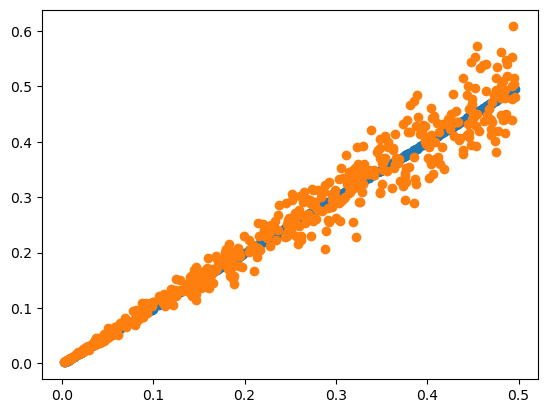

In [14]:
plt.scatter(Xs.numpy(), vanilla_predictions)
plt.scatter(Xs.numpy(), Ys.numpy())
plt.show()

In [15]:
inference_hidden = [64, 32, 16]
model = vids.VIDS(
    embedding_net=embedding_net,
    embedding_dim=embedding_dim,
    output_dim=output_dim,
    task="regression",
    inference_hidden_dims=inference_hidden,
    kl_weight=0.009,
    variance_penalty=10,
)


In [16]:

# 3. Train VIDS
print("\n--- Training VIDS ---")
losses = vids.train_vids(
    model=model,
    train_x=Xs,
    train_y=Ys,
    num_environments=100,
    env_train_size=10,
    env_test_size=10,
    num_steps=300,
    lr=1e-3,
)


--- Training VIDS ---
  Step 30/300, Loss: 7715.5483
  Step 60/300, Loss: 5511.4521
  Step 90/300, Loss: 2800.6921
  Step 120/300, Loss: 657.7250
  Step 150/300, Loss: 341.2232
  Step 180/300, Loss: 218.1143
  Step 210/300, Loss: 121.7013


KeyboardInterrupt: 

In [17]:
print("\n--- Predicting with uncertainty ---")
results = model.predict(Xs, new_Xs, num_samples=100)

pred_mean = results["predictions"].squeeze().cpu()
pred_std = results["std"].squeeze().cpu()
test_y_cpu = new_Ys.cpu()

rmse = torch.sqrt(torch.mean((pred_mean - test_y_cpu) ** 2))
print(f"\nRMSE: {rmse.item():.4f}")
print(f"Mean predicted std: {pred_std.mean().item():.4f}")


--- Predicting with uncertainty ---

RMSE: 0.4454
Mean predicted std: 0.4659


In [18]:
results.keys()

dict_keys(['predictions', 'std', 'samples'])

In [19]:
preds = results['predictions']

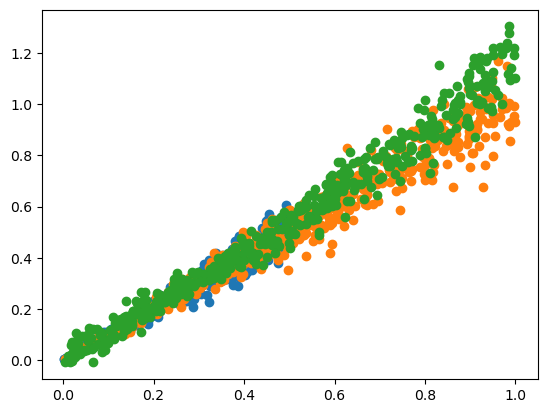

In [20]:
plt.scatter(Xs[:,0], Ys[:,0])
plt.scatter(new_Xs[:,0], new_Ys[:,0])
plt.scatter(new_Xs[:,0], preds[:,0])
plt.show()

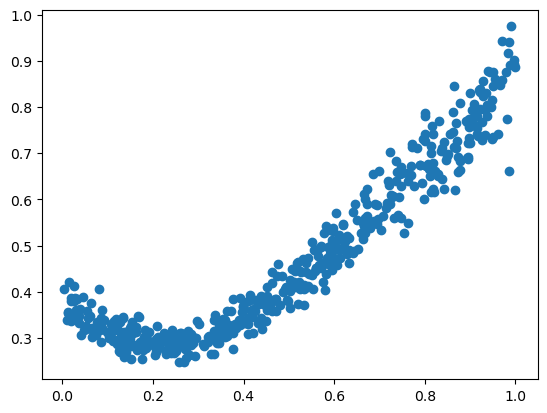

In [21]:
plt.scatter(new_Xs[:,0], results['std'][:,0])
plt.show()